# Fashion Product Classification – EfficientNetV2 Image Branch

This notebook develops the image-only branch of a multimodal fashion product classification framework.

A pretrained **EfficientNetV2B0** model is used to classify fashion product images across **90 article categories**. Training is performed in two stages:

1. Frozen feature extraction using ImageNet-pretrained weights
2. Fine-tuning of the final EfficientNetV2 layers

The best fine-tuned model is later reused as the image feature extractor in the multimodal fusion model.


## 1. Environment Setup

Google Drive is mounted to access the saved dataset splits, label encoder, trained models, and experiment results. The Kaggle package is also installed to download the fashion product image dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q kaggle

from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

## 2. Download and Locate the Image Dataset

The Fashion Product Images Small dataset is downloaded from Kaggle. Only the image files are used here because the cleaned training, validation, and test metadata splits were prepared previously and stored in Google Drive.


In [3]:
DATASET_FOLDER = "/content/fashion_dataset"
IMAGE_FOLDER = os.path.join(DATASET_FOLDER, "images")
DATASET_ZIP_PATH = os.path.join(
    DATASET_FOLDER,
    "fashion-product-images-small.zip"
)

os.makedirs(DATASET_FOLDER, exist_ok=True)

if not os.path.exists(IMAGE_FOLDER):
    print("Downloading the image dataset...")

    !kaggle datasets download \
        -d paramaggarwal/fashion-product-images-small \
        -p "$DATASET_FOLDER"

    print("Extracting the image dataset...")

    !unzip -q \
        "$DATASET_ZIP_PATH" \
        -d "$DATASET_FOLDER"
else:
    print("Image dataset already exists. Download skipped.")

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:27<00:00, 21.9MB/s]

Extracting the image dataset...


In [4]:
print("Dataset folder:", DATASET_FOLDER)
print("Image folder:", IMAGE_FOLDER)
print("Image folder exists:", os.path.exists(IMAGE_FOLDER))

if not os.path.exists(IMAGE_FOLDER):
    raise FileNotFoundError(f"Image folder not found: {IMAGE_FOLDER}")

print("Number of image files:", len(os.listdir(IMAGE_FOLDER)))


Dataset folder: /content/fashion_dataset
Image folder: /content/fashion_dataset/images
Image folder exists: True
Number of image files: 44441


## 3. Project Configuration

This section defines the Google Drive project paths, model checkpoints, result files, image dimensions, batch size, and reproducibility settings.

The same train, validation, and test splits are used across the image-only, text-only, and multimodal experiments to ensure a fair comparison.

In [5]:
import pickle
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.applications import EfficientNetV2B0

PROJECT_DIR = "/content/drive/MyDrive/fashion_multimodal_project"

TRAIN_PATH = os.path.join(PROJECT_DIR, "train.csv")
VAL_PATH = os.path.join(PROJECT_DIR, "val.csv")
TEST_PATH = os.path.join(PROJECT_DIR, "test.csv")
LABEL_ENCODER_PATH = os.path.join(PROJECT_DIR, "label_encoder.pkl")

STAGE1_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "efficientnetv2_image_best.keras"
)
FINE_TUNED_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "efficientnetv2_image_finetuned_best.keras"
)

STAGE1_HISTORY_PATH = os.path.join(
    PROJECT_DIR,
    "efficientnetv2_stage1_history.csv"
)
STAGE2_HISTORY_PATH = os.path.join(
    PROJECT_DIR,
    "efficientnetv2_stage2_history.csv"
)
STAGE1_RESULTS_PATH = os.path.join(
    PROJECT_DIR,
    "efficientnetv2_stage1_test_results.csv"
)
FINE_TUNED_RESULTS_PATH = os.path.join(
    PROJECT_DIR,
    "efficientnetv2_finetuned_test_results.csv"
)
COMPARISON_RESULTS_PATH = os.path.join(
    PROJECT_DIR,
    "efficientnetv2_model_comparison.csv"
)

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("Project directory:", PROJECT_DIR)


TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Project directory: /content/drive/MyDrive/fashion_multimodal_project


## 4. Load Dataset Splits and Label Encoder

The cleaned dataset has already been divided into training, validation, and test sets. The saved label encoder maps each article type to its corresponding numerical class label.

In [6]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

with open(LABEL_ENCODER_PATH, "rb") as file:
    label_encoder = pickle.load(file)

NUM_CLASSES = len(label_encoder.classes_)

print(f"Training samples: {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Number of classes: {NUM_CLASSES}")

Training samples: 30,814
Validation samples: 4,402
Test samples: 8,804
Number of classes: 90


In [7]:
encoder_classes = set(label_encoder.classes_)

for split_name, dataframe in {
    "Training": train_df,
    "Validation": val_df,
    "Test": test_df,
}.items():
    split_classes = set(dataframe["articleType"].unique())
    unknown_classes = split_classes - encoder_classes

    print(f"{split_name} class count: {len(split_classes)}")
    print(f"{split_name} unknown classes: {len(unknown_classes)}")

    if unknown_classes:
        raise ValueError(
            f"{split_name} contains classes that are not present "
            f"in the saved label encoder: {sorted(unknown_classes)}"
        )

print("Encoder class count:", len(encoder_classes))
print("All dataset classes are compatible with the label encoder.")

Training class count: 90
Training unknown classes: 0
Validation class count: 90
Validation unknown classes: 0
Test class count: 90
Test unknown classes: 0
Encoder class count: 90
All dataset classes are compatible with the label encoder.


## 5. Construct and Validate Image Paths

Each product ID is mapped to its corresponding JPEG image. The paths are validated before training to ensure that all rows have an available image.


In [8]:
def add_image_paths(dataframe):
    dataframe = dataframe.copy()
    dataframe["image_path"] = dataframe["id"].astype(str).apply(
        lambda image_id: os.path.join(IMAGE_FOLDER, f"{image_id}.jpg")
    )
    return dataframe


train_df = add_image_paths(train_df)
val_df = add_image_paths(val_df)
test_df = add_image_paths(test_df)

In [9]:
for split_name, dataframe in {
    "Training": train_df,
    "Validation": val_df,
    "Test": test_df,
}.items():
    missing_count = (~dataframe["image_path"].apply(os.path.exists)).sum()
    print(f"{split_name} missing images: {missing_count}")

    if missing_count > 0:
        raise FileNotFoundError(
            f"{missing_count} image files are missing from the {split_name} split."
        )

display(train_df[["id", "articleType", "label", "image_path"]].head())

Training missing images: 0
Validation missing images: 0
Test missing images: 0


,id,articleType,label,image_path
0,46825,Casual Shoes,12,/content/fashion_dataset/images/46825.jpg
1,42954,Belts,4,/content/fashion_dataset/images/42954.jpg
2,22584,Shorts,68,/content/fashion_dataset/images/22584.jpg
3,51581,Watches,89,/content/fashion_dataset/images/51581.jpg
4,18223,Socks,70,/content/fashion_dataset/images/18223.jpg


## 6. Image Preprocessing and TensorFlow Data Pipeline

Image paths and integer labels are converted into TensorFlow datasets. Every image is decoded as RGB, resized to **224 × 224**, cast to `float32`, batched, and prefetched.

EfficientNetV2B0 is created with `include_preprocessing=True`, so an additional manual division by 255 is not applied.

In [10]:
train_paths = train_df["image_path"].astype(str).values
train_labels = train_df["label"].astype("int32").values

val_paths = val_df["image_path"].astype(str).values
val_labels = val_df["label"].astype("int32").values

test_paths = test_df["image_path"].astype(str).values
test_labels = test_df["label"].astype("int32").values

In [11]:
def load_and_preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

In [12]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

train_ds = (
    train_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [13]:
for image_batch, label_batch in train_ds.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Image dtype:", image_batch.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>


## 7. Data Augmentation

Light augmentation is applied only during training. Horizontal flipping, small rotations, zooming, and contrast adjustments help improve generalisation while preserving the visual identity of the fashion products.

In [14]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation"
)

## 8. Build the EfficientNetV2 Image Classifier

EfficientNetV2B0 is initialized with ImageNet weights and used without its original classification head. During Stage 1, the backbone is frozen.

The custom classification head consists of:

- Global average pooling
- Dropout
- A 256-dimensional dense image embedding
- A second dropout layer
- A 90-class softmax output layer


In [15]:
base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
    include_preprocessing=True
)

base_model.trainable = False

inputs = layers.Input(
    shape=(*IMG_SIZE, 3),
    name="image_input"
)

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.3, name="stage1_dropout")(x)

x = layers.Dense(
    256,
    activation="relu",
    name="image_embedding"
)(x)

x = layers.Dropout(0.3, name="embedding_dropout")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="article_type_output"
)(x)

image_model = Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetV2_Image_Classifier"
)

image_model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetV2_Image_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stage1_dropout (Dropout)        │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ image_embedding (Dense)         │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dropout (Dropout)     │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ article_type_output (Dense)     │ (None, 90)             │        23,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,270,378 (23.92 MB)

 Trainable params: 351,066 (1.34 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

## 9. Stage 1: Frozen Feature Extraction

The EfficientNetV2 backbone remains frozen while the custom classification head is trained. The model is optimized with Adam using a learning rate of `1e-3`.

The best validation-accuracy checkpoint is saved, while early stopping and learning-rate reduction help control overfitting.


In [16]:
image_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

stage1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=STAGE1_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [17]:
history_stage1 = image_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=stage1_callbacks
)

Epoch 1/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6421 - loss: 1.4048 - top_5_accuracy: 0.8624
Epoch 1: val_accuracy improved from None to 0.81236, saving model to /content/drive/MyDrive/fashion_multimodal_project/efficientnetv2_image_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/fashion_multimodal_project/efficientnetv2_image_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 103s 88ms/step - accuracy: 0.7237 - loss: 0.9745 - top_5_accuracy: 0.9345 - val_accuracy: 0.8124 - val_loss: 0.5796 - val_top_5_accuracy: 0.9800 - learning_rate: 0.0010
Epoch 2/10
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7902 - loss: 0.6504 - top_5_accuracy: 0.9804
Epoch 2: val_accuracy improved from 0.81236 to 0.83644, saving model to /content/drive/MyDrive/fashion_multimodal_project/efficientnetv2_image_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/fashion_multimodal_project/efficientnetv2_image_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 76s 79ms/s

In [18]:
history_stage1_df = pd.DataFrame(history_stage1.history)
history_stage1_df.to_csv(STAGE1_HISTORY_PATH, index=False)

history_stage1_df

,accuracy,loss,top_5_accuracy,val_accuracy,val_loss,val_top_5_accuracy,learning_rate
0,0.723665,0.974494,0.934543,0.812358,0.579571,0.980009,0.0010
1,0.796164,0.636231,0.979879,0.836438,0.508173,0.987051,0.0010
2,0.812098,0.568908,0.985299,0.840527,0.484335,0.988642,0.0010
3,0.821510,0.537128,0.987506,0.848251,0.448667,0.992049,0.0010
4,0.827546,0.511619,0.989420,0.849387,0.462139,0.990005,0.0010
5,0.833615,0.487548,0.990556,0.853476,0.450417,0.991822,0.0010
6,0.852145,0.427000,0.993477,0.868469,0.409689,0.992276,0.0002
7,0.856559,0.410907,0.993185,0.871422,0.406824,0.992731,0.0002
8,0.862303,0.397983,0.994775,0.870286,0.406813,0.992731,0.0002
9,0.861037,0.393958,0.994645,0.868242,0.403091,0.993412,0.0002


## 10. Stage 1 Training Behaviour

The training and validation curves are visualized to assess convergence and monitor the learning behaviour during frozen feature extraction.

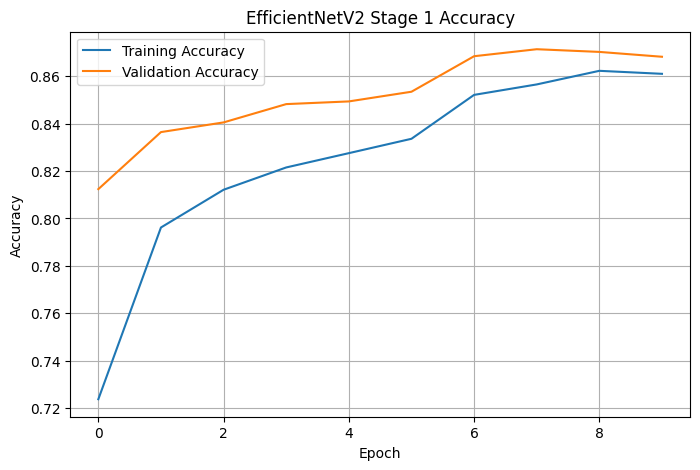

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history_stage1.history["accuracy"], label="Training Accuracy")
plt.plot(history_stage1.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetV2 Stage 1 Accuracy")
plt.legend()
plt.grid()
plt.show()

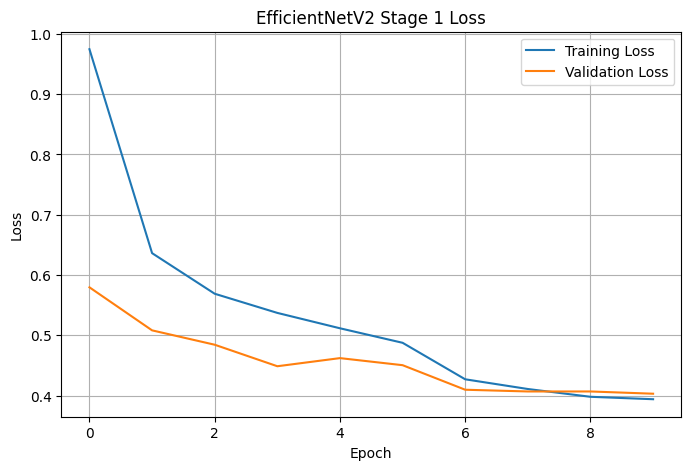

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(history_stage1.history["loss"], label="Training Loss")
plt.plot(history_stage1.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetV2 Stage 1 Loss")
plt.legend()
plt.grid()
plt.show()

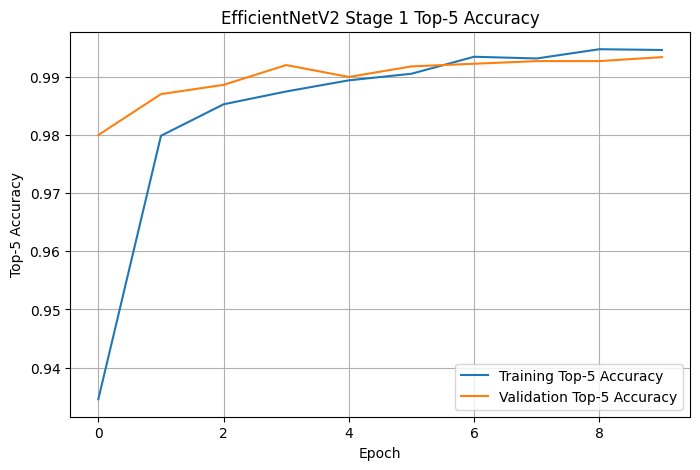

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_stage1.history["top_5_accuracy"],
    label="Training Top-5 Accuracy"
)

plt.plot(
    history_stage1.history["val_top_5_accuracy"],
    label="Validation Top-5 Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Top-5 Accuracy")
plt.title("EfficientNetV2 Stage 1 Top-5 Accuracy")
plt.legend()
plt.grid()
plt.show()

## 11. Stage 1 Evaluation

The best frozen-backbone checkpoint is restored and evaluated on the held-out test dataset. The resulting metrics are saved directly from the evaluation dictionary rather than manually typing values.

In [26]:
best_image_model = tf.keras.models.load_model(STAGE1_MODEL_PATH)
print("Best Stage 1 model loaded.")

Best Stage 1 model loaded.


In [27]:
stage1_test_results = best_image_model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

stage1_test_results

276/276 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.8661 - loss: 0.3983 - top_5_accuracy: 0.9933


{'accuracy': 0.8660836219787598,
 'loss': 0.39832553267478943,
 'top_5_accuracy': 0.9932984709739685}

In [28]:
stage1_results_df = pd.DataFrame([{
    "Model": "EfficientNetV2B0 Image-Only",
    "Stage": "Frozen feature extractor",
    "Test Loss": stage1_test_results["loss"],
    "Test Accuracy": stage1_test_results["accuracy"],
    "Test Top-5 Accuracy": stage1_test_results["top_5_accuracy"]
}])

stage1_results_df.to_csv(STAGE1_RESULTS_PATH, index=False)
stage1_results_df

,Model,Stage,Test Loss,Test Accuracy,Test Top-5 Accuracy
0,EfficientNetV2B0 Image-Only,Frozen feature extractor,0.398326,0.866084,0.993298


## 12. Stage 2: Fine-Tuning

The EfficientNetV2 backbone from the best Stage 1 model is unfrozen. Only the final 30 backbone layers are made trainable, while all Batch Normalization layers remain frozen to support stable fine-tuning.

The model is recompiled with a smaller learning rate of `1e-5` before training.


In [29]:
base_model = best_image_model.get_layer("efficientnetv2-b0")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Total base-model layers:", len(base_model.layers))
print(
    "Trainable base-model layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total base-model layers: 270
Trainable base-model layers: 24


In [30]:
best_image_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ]
)

fine_tune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=FINE_TUNED_MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

In [31]:
history_stage2 = best_image_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=fine_tune_callbacks
)

Epoch 1/5
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8646 - loss: 0.3905 - top_5_accuracy: 0.9960
Epoch 1: val_accuracy improved from None to 0.87097, saving model to /content/drive/MyDrive/fashion_multimodal_project/efficientnetv2_image_finetuned_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/fashion_multimodal_project/efficientnetv2_image_finetuned_best.keras
963/963 ━━━━━━━━━━━━━━━━━━━━ 106s 93ms/step - accuracy: 0.8661 - loss: 0.3861 - top_5_accuracy: 0.9952 - val_accuracy: 0.8710 - val_loss: 0.4012 - val_top_5_accuracy: 0.9936 - learning_rate: 1.0000e-05
Epoch 2/5
963/963 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8683 - loss: 0.3780 - top_5_accuracy: 0.9952
Epoch 2: val_accuracy improved from 0.87097 to 0.87233, saving model to /content/drive/MyDrive/fashion_multimodal_project/efficientnetv2_image_finetuned_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/fashion_multimodal_project/efficientnetv2_image_finetuned_best.ker

In [32]:
history_stage2_df = pd.DataFrame(history_stage2.history)
history_stage2_df.to_csv(STAGE2_HISTORY_PATH, index=False)

history_stage2_df

,accuracy,loss,top_5_accuracy,val_accuracy,val_loss,val_top_5_accuracy,learning_rate
0,0.866132,0.386142,0.995197,0.870968,0.401223,0.993639,0.00001
1,0.868631,0.377841,0.995359,0.872331,0.396237,0.992958,0.00001
2,0.870091,0.373610,0.995132,0.871876,0.393691,0.993639,0.00001
3,0.871130,0.368778,0.995359,0.875057,0.390359,0.993412,0.00001
4,0.873239,0.365864,0.995165,0.875511,0.387691,0.993412,0.00001


## 13. Fine-Tuned Model Evaluation

The best fine-tuned checkpoint is restored and evaluated on the same held-out test dataset used for Stage 1.


In [33]:
fine_tuned_model = tf.keras.models.load_model(
    FINE_TUNED_MODEL_PATH
)

print("Best fine-tuned model loaded.")

Best fine-tuned model loaded.


In [34]:
fine_tuned_test_results = fine_tuned_model.evaluate(
    test_ds,
    verbose=1,
    return_dict=True
)

fine_tuned_test_results

276/276 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step - accuracy: 0.8720 - loss: 0.3809 - top_5_accuracy: 0.9935


{'accuracy': 0.8719900250434875,
 'loss': 0.3808807134628296,
 'top_5_accuracy': 0.9935256838798523}

In [35]:
fine_tuned_results_df = pd.DataFrame([{
    "Model": "EfficientNetV2B0 Image-Only",
    "Stage": "Fine-tuned",
    "Test Loss": fine_tuned_test_results["loss"],
    "Test Accuracy": fine_tuned_test_results["accuracy"],
    "Test Top-5 Accuracy": fine_tuned_test_results["top_5_accuracy"]
}])

fine_tuned_results_df.to_csv(
    FINE_TUNED_RESULTS_PATH,
    index=False
)

fine_tuned_results_df

,Model,Stage,Test Loss,Test Accuracy,Test Top-5 Accuracy
0,EfficientNetV2B0 Image-Only,Fine-tuned,0.380881,0.87199,0.993526


## 14. Model Comparison

The frozen and fine-tuned EfficientNetV2 models are compared using test loss, Top-1 accuracy, and Top-5 accuracy. All values are taken directly from the model evaluation outputs.

In [36]:
comparison_df = pd.DataFrame({
    "Model Stage": [
        "Frozen EfficientNetV2",
        "Fine-tuned EfficientNetV2"
    ],
    "Test Accuracy": [
        stage1_test_results["accuracy"],
        fine_tuned_test_results["accuracy"]
    ],
    "Test Top-5 Accuracy": [
        stage1_test_results["top_5_accuracy"],
        fine_tuned_test_results["top_5_accuracy"]
    ],
    "Test Loss": [
        stage1_test_results["loss"],
        fine_tuned_test_results["loss"]
    ]
})

comparison_df.to_csv(COMPARISON_RESULTS_PATH, index=False)
comparison_df

,Model Stage,Test Accuracy,Test Top-5 Accuracy,Test Loss
0,Frozen EfficientNetV2,0.866084,0.993298,0.398326
1,Fine-tuned EfficientNetV2,0.871990,0.993526,0.380881


## 15. Conclusion

An EfficientNetV2B0-based image classifier was developed for fashion product recognition across **90 article categories**.

Training was completed in two stages:

1. Frozen feature extraction
2. Fine-tuning of the final EfficientNetV2 layers

The fine-tuned checkpoint is saved as `efficientnetv2_image_finetuned_best.keras` and is reused as the image feature extractor in the multimodal fusion notebook.